<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/Structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# $O_{3}$


Total R²: -0.662

R² per Type:
Traffic: -2.185
Industrial: -0.882
Background: -0.604


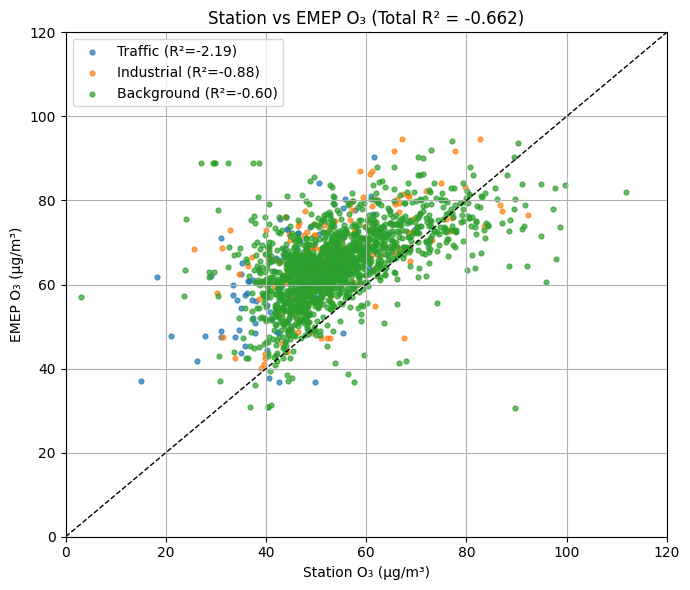

In [16]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from sklearn.metrics import r2_score

# ======================================================
#  Load Stations
# ======================================================
stations = pd.read_csv("yearly_O3_2015.csv")

station_lats = stations["Latitude"].values
station_lons = stations["Longitude"].values
station_values = stations["Average"].values
station_types = stations["Type"].values

# ======================================================
#  Load EMEP Grid
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lats = ds["lat"].values
lons = ds["lon"].values
o3_grid = ds["SURF_ug_O3"].isel(time=0).values

# ======================================================
#  Grid Cell Centres
# ======================================================
lon_grid, lat_grid = np.meshgrid(lons, lats)

grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
grid_points_rad = np.radians(grid_points)
o3_flat = o3_grid.ravel()

# ======================================================
#  Station → Grid Matching (NO averaging)
# ======================================================
station_coords = np.column_stack((station_lats, station_lons))
station_coords_rad = np.radians(station_coords)

tree = BallTree(grid_points_rad, metric="haversine")
dist, ind = tree.query(station_coords_rad, k=1)

emep_values = o3_flat[ind.flatten()]

# ======================================================
#  Total R²
# ======================================================
r2_total = r2_score(station_values, emep_values)

# ======================================================
#  R² per Type
# ======================================================
r2_per_type = {}

unique_types = stations["Type"].unique()

for t in unique_types:
    mask = station_types == t
    if np.sum(mask) > 1:
        r2_per_type[t] = r2_score(
            station_values[mask],
            emep_values[mask]
        )

print("\nTotal R²:", round(r2_total, 3))
print("\nR² per Type:")
for t, val in r2_per_type.items():
    print(f"{t}: {val:.3f}")

# ======================================================
#  Scatter Plot
# ======================================================
plt.figure(figsize=(7,6))

for t in unique_types:
    mask = station_types == t
    plt.scatter(
        station_values[mask],      # X = Stations
        emep_values[mask],         # Y = EMEP
        s=12,
        alpha=0.7,
        label=f"{t} (R²={r2_per_type.get(t, np.nan):.2f})"
    )

# 1:1 Line
plt.plot([0,120], [0,120], 'k--', linewidth=1)

plt.xlim(0,120)
plt.ylim(0,120)

plt.xlabel("Station O₃ (μg/m³)")
plt.ylabel("EMEP O₃ (μg/m³)")
plt.title(f"Station vs EMEP O₃ (Total R² = {r2_total:.3f})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
df = pd.read_csv("yearly_O3_2015.csv")

counts = df["Type"].value_counts()
percent = 100 * counts / len(df)

summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percent.round(2)
})

print(summary)

            Count  Percentage (%)
Type                             
Background   1480           84.38
Industrial    157            8.95
Traffic       117            6.67



Total R²: -0.662

R² per Area:
Urban: -2.534
Suburban: -1.522
Rural: 0.121


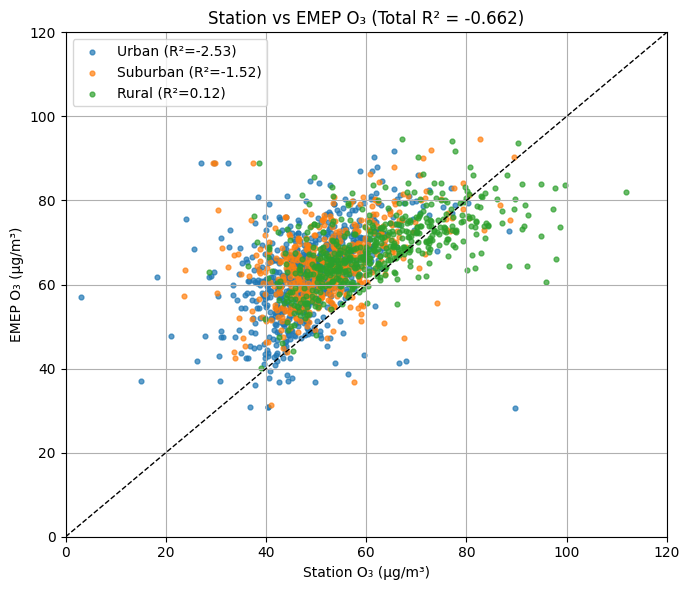

In [18]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from sklearn.metrics import r2_score

# ======================================================
#  Load Stations
# ======================================================
stations = pd.read_csv("yearly_O3_2015.csv")

station_lats = stations["Latitude"].values
station_lons = stations["Longitude"].values
station_values = stations["Average"].values
station_area = stations["Area"].values   # <-- use Area

# ======================================================
#  Load EMEP Grid
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lats = ds["lat"].values
lons = ds["lon"].values
o3_grid = ds["SURF_ug_O3"].isel(time=0).values

# ======================================================
#  Grid Cell Centres
# ======================================================
lon_grid, lat_grid = np.meshgrid(lons, lats)

grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
grid_points_rad = np.radians(grid_points)
o3_flat = o3_grid.ravel()

# ======================================================
# Station → Grid Matching (NO averaging)
# ======================================================
station_coords = np.column_stack((station_lats, station_lons))
station_coords_rad = np.radians(station_coords)

tree = BallTree(grid_points_rad, metric="haversine")
dist, ind = tree.query(station_coords_rad, k=1)

emep_values = o3_flat[ind.flatten()]

# ======================================================
#  Total R²
# ======================================================
r2_total = r2_score(station_values, emep_values)

# ======================================================
#  R² per Area
# ======================================================
r2_per_area = {}

unique_areas = stations["Area"].unique()

for area in unique_areas:
    mask = station_area == area
    if np.sum(mask) > 1:
        r2_per_area[area] = r2_score(
            station_values[mask],
            emep_values[mask]
        )

print("\nTotal R²:", round(r2_total, 3))
print("\nR² per Area:")
for area, val in r2_per_area.items():
    print(f"{area}: {val:.3f}")

# ======================================================
#  Scatter Plot
# ======================================================
plt.figure(figsize=(7,6))

for area in unique_areas:
    mask = station_area == area
    plt.scatter(
        station_values[mask],      # X = Stations
        emep_values[mask],         # Y = EMEP
        s=12,
        alpha=0.7,
        label=f"{area} (R²={r2_per_area.get(area, np.nan):.2f})"
    )

# 1:1 line
plt.plot([0,120], [0,120], 'k--', linewidth=1)

plt.xlim(0,120)
plt.ylim(0,120)

plt.xlabel("Station O₃ (μg/m³)")
plt.ylabel("EMEP O₃ (μg/m³)")
plt.title(f"Station vs EMEP O₃ (Total R² = {r2_total:.3f})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
df = pd.read_csv("yearly_O3_2015.csv")

counts = df["Area"].value_counts()
percent = 100 * counts / len(df)

summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percent.round(2)
})

print(summary)

          Count  Percentage (%)
Area                           
Urban       763           43.50
Rural       522           29.76
Suburban    469           26.74


# $NO_{2}$


NO2 Total R²: -0.218

NO2 R² per Type:
Industrial: -0.464
Background: -0.025
Traffic: -2.024


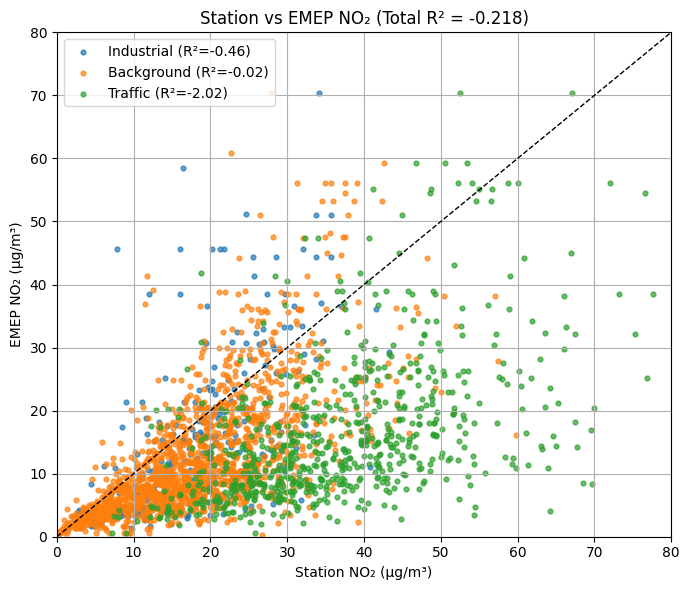

In [26]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from sklearn.metrics import r2_score

# ======================================================
#  Load NO2 Stations
# ======================================================
stations = pd.read_csv("yearly_NO2_2015.csv")

station_lats = stations["Latitude"].values
station_lons = stations["Longitude"].values
station_values = stations["Average"].values
station_types = stations["Type"].values

# ======================================================
#  Load EMEP Grid (NO2)
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lats = ds["lat"].values
lons = ds["lon"].values
no2_grid = ds["SURF_ug_NO2"].isel(time=0).values

# ======================================================
#  Grid Cell Centres
# ======================================================
lon_grid, lat_grid = np.meshgrid(lons, lats)

grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
grid_points_rad = np.radians(grid_points)
no2_flat = no2_grid.ravel()

# ======================================================
#  Station → Grid Matching (NO averaging)
# ======================================================
station_coords = np.column_stack((station_lats, station_lons))
station_coords_rad = np.radians(station_coords)

tree = BallTree(grid_points_rad, metric="haversine")
dist, ind = tree.query(station_coords_rad, k=1)

emep_values = no2_flat[ind.flatten()]

# ======================================================
#  Total R²
# ======================================================
r2_total = r2_score(station_values, emep_values)

# ======================================================
#  R² per Type
# ======================================================
r2_per_type = {}

unique_types = stations["Type"].unique()

for t in unique_types:
    mask = station_types == t
    if np.sum(mask) > 1:
        r2_per_type[t] = r2_score(
            station_values[mask],
            emep_values[mask]
        )

print("\nNO2 Total R²:", round(r2_total, 3))
print("\nNO2 R² per Type:")
for t, val in r2_per_type.items():
    print(f"{t}: {val:.3f}")

# ======================================================
#  Scatter Plot
# ======================================================
plt.figure(figsize=(7,6))

for t in unique_types:
    mask = station_types == t
    plt.scatter(
        station_values[mask],      # X = Stations
        emep_values[mask],         # Y = EMEP
        s=12,
        alpha=0.7,
        label=f"{t} (R²={r2_per_type.get(t, np.nan):.2f})"
    )

# 1:1 Line
plt.plot([0,80], [0,80], 'k--', linewidth=1)

plt.xlim(0,80)
plt.ylim(0,80)

plt.xlabel("Station NO₂ (μg/m³)")
plt.ylabel("EMEP NO₂ (μg/m³)")
plt.title(f"Station vs EMEP NO₂ (Total R² = {r2_total:.3f})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
df = pd.read_csv("yearly_NO2_2015.csv")

counts = df["Type"].value_counts()
percent = 100 * counts / len(df)

summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percent.round(2)
})

print(summary)

            Count  Percentage (%)
Type                             
Background   1510           59.17
Traffic       734           28.76
Industrial    308           12.07



NO2 Total R²: -0.218

NO2 R² per Area:
Suburban: -0.654
Urban: -0.757
Rural: 0.268


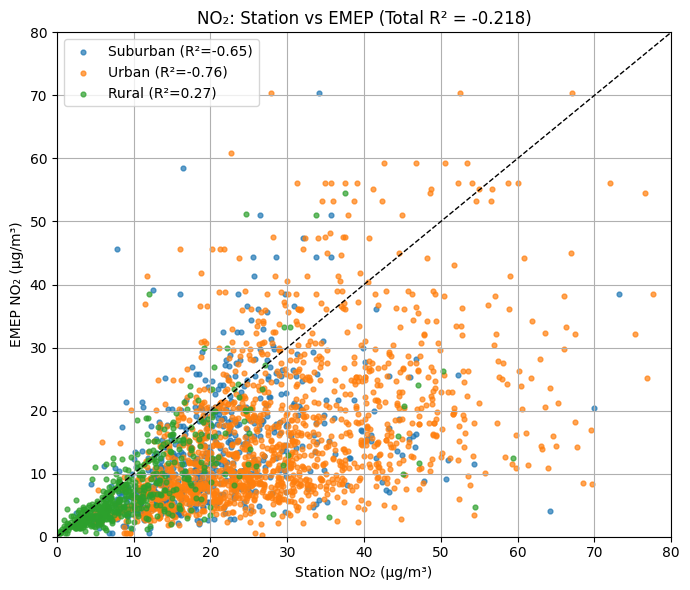

In [23]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from sklearn.metrics import r2_score

# ======================================================
# Load NO2 Stations
# ======================================================
stations = pd.read_csv("yearly_NO2_2015.csv")

station_values = stations["Average"].values
station_lats = stations["Latitude"].values
station_lons = stations["Longitude"].values
station_area = stations["Area"].values

# ======================================================
#  Load EMEP NO2
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lats = ds["lat"].values
lons = ds["lon"].values
no2_grid = ds["SURF_ug_NO2"].isel(time=0).values

# ======================================================
#  Build Grid
# ======================================================
lon_grid, lat_grid = np.meshgrid(lons, lats)

grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
grid_points_rad = np.radians(grid_points)
no2_flat = no2_grid.ravel()

# ======================================================
#  Match Stations → Grid
# ======================================================
station_coords = np.column_stack((station_lats, station_lons))
station_coords_rad = np.radians(station_coords)

tree = BallTree(grid_points_rad, metric="haversine")
dist, ind = tree.query(station_coords_rad, k=1)

model_values = no2_flat[ind.flatten()]

# ======================================================
#  R² Calculations
# ======================================================
r2_total = r2_score(station_values, model_values)

r2_per_area = {}
unique_areas = stations["Area"].unique()

for area in unique_areas:
    mask = station_area == area
    if np.sum(mask) > 1:
        r2_per_area[area] = r2_score(
            station_values[mask],
            model_values[mask]
        )

print("\nNO2 Total R²:", round(r2_total, 3))
print("\nNO2 R² per Area:")
for area, val in r2_per_area.items():
    print(f"{area}: {val:.3f}")

# ======================================================
#  Scatter Plot
# ======================================================
plt.figure(figsize=(7,6))

for area in unique_areas:
    mask = station_area == area
    plt.scatter(
        station_values[mask],
        model_values[mask],
        s=12,
        alpha=0.7,
        label=f"{area} (R²={r2_per_area.get(area, np.nan):.2f})"
    )

# 1:1 line
plt.plot([0,80], [0,80], 'k--', linewidth=1)

plt.xlim(0,80)
plt.ylim(0,80)

plt.xlabel("Station NO₂ (μg/m³)")
plt.ylabel("EMEP NO₂ (μg/m³)")
plt.title(f"NO₂: Station vs EMEP (Total R² = {r2_total:.3f})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
df = pd.read_csv("yearly_NO2_2015.csv")

counts = df["Area"].value_counts()
percent = 100 * counts / len(df)

summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percent.round(2)
})

print(summary)

          Count  Percentage (%)
Area                           
Urban      1482           58.07
Suburban    584           22.88
Rural       486           19.04


# $PM_{2.5}$


PM2.5 Total R²: 0.349

PM2.5 R² per Type:
Traffic: 0.334
Industrial: 0.263
Background: 0.356


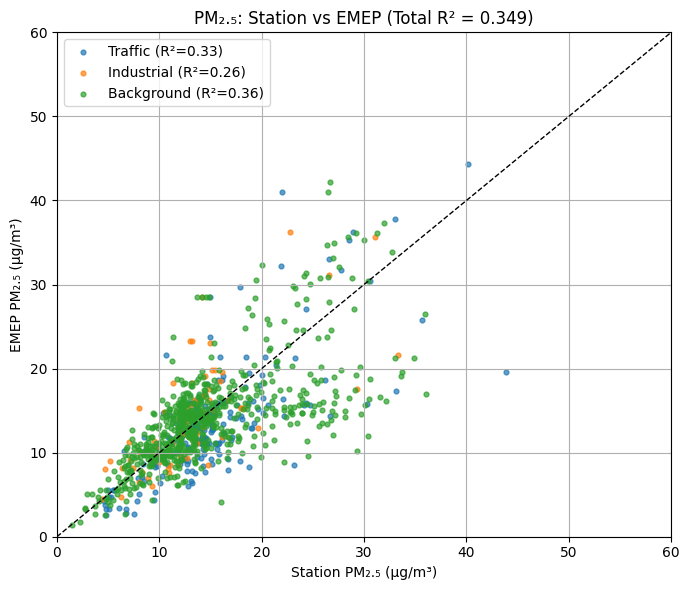

In [30]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from sklearn.metrics import r2_score

# ======================================================
#  Load PM2.5 Stations
# ======================================================
stations = pd.read_csv("yearly_PM25_2015.csv")

station_lats = stations["Latitude"].values
station_lons = stations["Longitude"].values
station_values = stations["Average"].values
station_types = stations["Type"].values

# ======================================================
#  Load EMEP Grid (PM2.5)
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lats = ds["lat"].values
lons = ds["lon"].values
pm_grid = ds["SURF_ug_PM25_rh50"].isel(time=0).values

# ======================================================
#  Grid Cell Centres
# ======================================================
lon_grid, lat_grid = np.meshgrid(lons, lats)

grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
grid_points_rad = np.radians(grid_points)
pm_flat = pm_grid.ravel()

# ======================================================
#  Station → Grid Matching
# ======================================================
station_coords = np.column_stack((station_lats, station_lons))
station_coords_rad = np.radians(station_coords)

tree = BallTree(grid_points_rad, metric="haversine")
dist, ind = tree.query(station_coords_rad, k=1)

emep_values = pm_flat[ind.flatten()]

# ======================================================
#  Total R²
# ======================================================
r2_total = r2_score(station_values, emep_values)

# ======================================================
#  R² per Type
# ======================================================
r2_per_type = {}
unique_types = stations["Type"].unique()

for t in unique_types:
    mask = station_types == t
    if np.sum(mask) > 1:
        r2_per_type[t] = r2_score(
            station_values[mask],
            emep_values[mask]
        )

print("\nPM2.5 Total R²:", round(r2_total, 3))
print("\nPM2.5 R² per Type:")
for t, val in r2_per_type.items():
    print(f"{t}: {val:.3f}")

# ======================================================
#  Scatter Plot
# ======================================================
plt.figure(figsize=(7,6))

for t in unique_types:
    mask = station_types == t
    plt.scatter(
        station_values[mask],
        emep_values[mask],
        s=12,
        alpha=0.7,
        label=f"{t} (R²={r2_per_type.get(t, np.nan):.2f})"
    )

plt.plot([0,60], [0,60], 'k--', linewidth=1)

plt.xlim(0,60)
plt.ylim(0,60)

plt.xlabel("Station PM₂.₅ (μg/m³)")
plt.ylabel("EMEP PM₂.₅ (μg/m³)")
plt.title(f"PM₂.₅: Station vs EMEP (Total R² = {r2_total:.3f})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [36]:
df = pd.read_csv("yearly_PM25_2015.csv")

counts = df["Type"].value_counts()
percent = 100 * counts / len(df)

summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percent.round(2)
})

print(summary)

            Count  Percentage (%)
Type                             
Background    643           67.90
Traffic       222           23.44
Industrial     82            8.66



PM2.5 Total R²: 0.349

PM2.5 R² per Area:
Urban: 0.261
Suburban: 0.278
Rural: 0.574


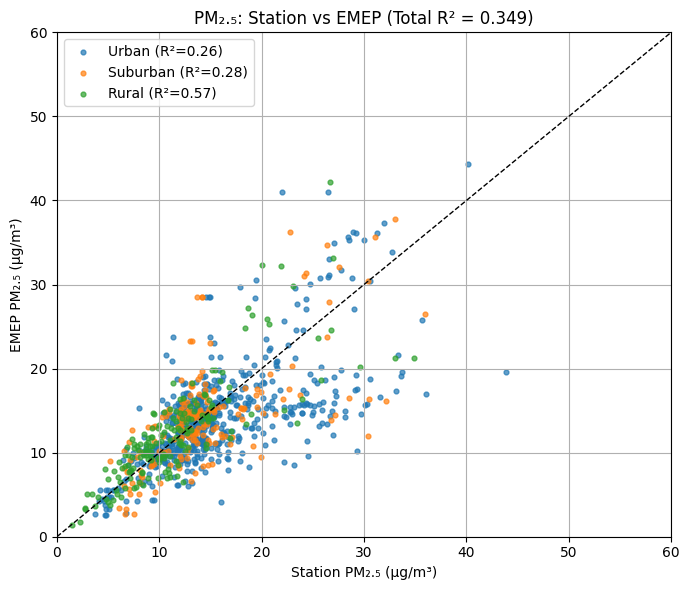

In [31]:
# ======================================================
#  R² per Area
# ======================================================
station_area = stations["Area"].values
r2_per_area = {}
unique_areas = stations["Area"].unique()

for area in unique_areas:
    mask = station_area == area
    if np.sum(mask) > 1:
        r2_per_area[area] = r2_score(
            station_values[mask],
            emep_values[mask]
        )

print("\nPM2.5 Total R²:", round(r2_total, 3))
print("\nPM2.5 R² per Area:")
for area, val in r2_per_area.items():
    print(f"{area}: {val:.3f}")

plt.figure(figsize=(7,6))

for area in unique_areas:
    mask = station_area == area
    plt.scatter(
        station_values[mask],
        emep_values[mask],
        s=12,
        alpha=0.7,
        label=f"{area} (R²={r2_per_area.get(area, np.nan):.2f})"
    )

plt.plot([0,60], [0,60], 'k--', linewidth=1)

plt.xlim(0,60)
plt.ylim(0,60)

plt.xlabel("Station PM₂.₅ (μg/m³)")
plt.ylabel("EMEP PM₂.₅ (μg/m³)")
plt.title(f"PM₂.₅: Station vs EMEP (Total R² = {r2_total:.3f})")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [37]:
df = pd.read_csv("yearly_PM25_2015.csv")

counts = df["Area"].value_counts()
percent = 100 * counts / len(df)

summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percent.round(2)
})

print(summary)

          Count  Percentage (%)
Area                           
Urban       588           62.09
Suburban    185           19.54
Rural       174           18.37
